# Download the dataset and upload it to colab from this [link](https://www.kaggle.com/datasets/riotulab/saudi-license-plate-characters/data)

##### Note that colab was used in development so minor changes might be required

In [ ]:
!unzip -q ../data/archive.zip -d /content/saudi-license-plate-characters

In [ ]:
!ls ../data/saudi-license-plate-characters

License-Characters-by-2-27classes


In [ ]:
import os
import shutil
import random

# Set your paths
SOURCE_TRAIN = "../data/saudi-license-plate-characters/License-Characters-by-2-27classes/train"
SOURCE_TEST  = "../data/saudi-license-plate-characters/License-Characters-by-2-27classes/test"
DEST         = "dataset"
VAL_SPLIT    = 0.10  # 10% of train → val

# Create destination folders
for split in ["train", "val", "test"]:
    os.makedirs(f"{DEST}/images/{split}", exist_ok=True)
    os.makedirs(f"{DEST}/labels/{split}", exist_ok=True)

def copy_files(src_dir, split):
    for fname in os.listdir(src_dir):
        src = os.path.join(src_dir, fname)
        if fname.endswith((".jpeg", ".jpg", ".png")):
            shutil.copy(src, f"{DEST}/images/{split}/{fname}")
        elif fname.endswith(".txt"):
            shutil.copy(src, f"{DEST}/labels/{split}/{fname}")


# Handle test set
copy_files(SOURCE_TEST, "test")

# split train into train/val
all_images = [f for f in os.listdir(SOURCE_TRAIN)
              if f.endswith((".jpeg", ".jpg", ".png"))]

random.seed(42)
random.shuffle(all_images)

val_count   = int(len(all_images) * VAL_SPLIT)
val_images  = set(all_images[:val_count])
train_images = set(all_images[val_count:])

for fname in os.listdir(SOURCE_TRAIN):
    src = os.path.join(SOURCE_TRAIN, fname)
    stem = os.path.splitext(fname)[0]  # filename without extension

    if fname.endswith((".jpeg", ".jpg", ".png")):
        split = "val" if fname in val_images else "train"
        shutil.copy(src, f"{DEST}/images/{split}/{fname}")
    elif fname.endswith((".txt", ".xml")):
        # Match label to its image's split
        img_name = next((img for img in all_images if os.path.splitext(img)[0] == stem), None)
        if img_name:
            split = "val" if img_name in val_images else "train"
            shutil.copy(src, f"{DEST}/labels/{split}/{fname}")

print(f"Train images: {len(os.listdir(f'{DEST}/images/train'))}")
print(f"Val images:   {len(os.listdir(f'{DEST}/images/val'))}")
print(f"Test images:  {len(os.listdir(f'{DEST}/images/test'))}")

Train images: 507
Val images:   56
Test images:  30


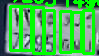

In [4]:
import cv2
from google.colab.patches import cv2_imshow

def visualize(images_dir, labels_dir):
    # pick random image
    img_file = random.choice(os.listdir(images_dir))
    img_path = os.path.join(images_dir, img_file)
    lbl_path = os.path.join(labels_dir, os.path.splitext(img_file)[0] + ".txt")

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    with open(lbl_path) as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.strip().split())
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, str(int(cls)), (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    cv2_imshow(img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

visualize("/content/dataset/images/train", "/content/dataset/labels/train")

In [5]:
# Extract label names from xml files to create .yaml file required for YOLO
import xml.etree.ElementTree as ET
from collections import defaultdict

xml_dir = "dataset/labels/train"
txt_dir = "dataset/labels/train"

# for each file, map class_id from txt to class_name from xml
class_map = {}

for fname in os.listdir(xml_dir):
    if fname.endswith(".xml"):
        stem = os.path.splitext(fname)[0]
        txt_path = os.path.join(txt_dir, stem + ".txt")
        xml_path = os.path.join(xml_dir, fname)

        if not os.path.exists(txt_path):
            continue

        # get names from xml in order
        tree = ET.parse(xml_path)
        names = [obj.find("name").text for obj in tree.getroot().findall("object")]

        # get class ids from txt in order
        with open(txt_path) as f:
            ids = [int(line.strip().split()[0]) for line in f]

        for cls_id, name in zip(ids, names):
            class_map[cls_id] = name

for cls_id in sorted(class_map.keys()):
    print(f"{cls_id}: {class_map[cls_id]}")

0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9
10: A
11: B
12: D
13: E
14: G
15: H
16: J
17: K
18: L
19: N
20: R
21: S
22: T
23: U
24: V
25: X
26: Z


In [6]:
import yaml

class_map = {
    0: "0", 1: "1", 2: "2", 3: "3", 4: "4",
    5: "5", 6: "6", 7: "7", 8: "8", 9: "9",
    10: "A", 11: "B", 12: "D", 13: "E", 14: "G",
    15: "H", 16: "J", 17: "K", 18: "L", 19: "N",
    20: "R", 21: "S", 22: "T", 23: "U", 24: "V",
    25: "X", 26: "Z"
}

data = {
    "path": "dataset",
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 27,
    "names": class_map
}

with open("dataset/data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=True, allow_unicode=True)

print("data.yaml created successfully")

data.yaml created successfully


In [7]:
with open("dataset/data.yaml") as f:
    print(f.read())

names:
  0: '0'
  1: '1'
  2: '2'
  3: '3'
  4: '4'
  5: '5'
  6: '6'
  7: '7'
  8: '8'
  9: '9'
  10: A
  11: B
  12: D
  13: E
  14: G
  15: H
  16: J
  17: K
  18: L
  19: N
  20: R
  21: S
  22: T
  23: U
  24: V
  25: X
  26: Z
nc: 27
path: dataset
test: images/test
train: images/train
val: images/val



In [8]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.5 MB/s eta 0:00:00


In [9]:
import albumentations as A
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

augmentations = [
    A.BBoxSafeRandomCrop(p=0.5),
    A.Resize(640, 640),
    A.RandomBrightnessContrast(p=0.2),
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.CoarseDropout(num_holes_range=(1, 2), hole_height_range=(0.1, 0.25),
                        hole_width_range=(0.1, 0.25), p=1.0),
        A.GridDropout(ratio=0.5, unit_size_range=(10, 20), p=1.0)
    ], p=0.5)
]

results = model.train(
    data="dataset/data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    augmentations=augmentations
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[BBoxSafeRandomCrop(p=0.5, erosion_rate=0.0), Resize(p=1.0, area_for_downscale=None, height=640, interpolation=1, mask_interpolation=0, width=640), RandomBrightnessContrast(p=0.2, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False), HorizontalFlip(p=0.5), OneOf([
  CoarseDropout(p=1.0, fill=0.0, fill_mask=None, hole_height_range=(0.1, 0.25), hole_width_range=(0.1, 0.25), num_holes_range=(1, 2)),
  GridDropout(p=1.0, fill=0.0, fill_mask=None, holes_number_xy=Non


image 1/1 /content/dataset/images/test/ckicz5mvn001m246adc3vvpi8.jpeg: 320x640 1 4, 2 5s, 1 8, 1 D, 1 J, 1 U, 49.0ms
Speed: 1.3ms preprocess, 49.0ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 640)


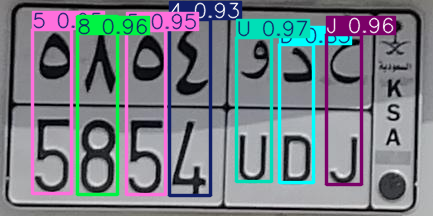

In [10]:
model = YOLO("runs/detect/train/weights/best.pt")

# pick a random test image
test_dir = "dataset/images/test"
img_file = random.choice(os.listdir(test_dir))
img_path = os.path.join(test_dir, img_file)

results = model.predict(img_path, conf=0.616)  # use the best confidence threshold
results[0].show()  # displays the image with boxes and class labels

In [12]:
from google.colab import files
model.export(format='onnx')

files.download('/content/runs/detect/train/weights/best.pt')
files.download('/content/runs/detect/train/weights/best.onnx')
files.download('/content/runs/detect/train/weights/last.pt')
files.download('/content/runs/detect/train/results.csv')

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 31, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 248ms
Prepared 4 packages in 3.41s
Installed 4 packages in 282ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 4.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 6.5s, saved as 'runs/detect/train/wei

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>